In [1]:
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Uniform
from probjax.distributions.independent import Independent
from probjax.core import inverse_and_logabsdet, inverse
from probjax.core.jaxpr_propagation.graph import JaxprGraph
from probjax.nn.bijective import rational_quadratic_spline
import matplotlib.pyplot as plt

import haiku as hk
from probjax.nn.coupling import CouplingMLP
from probjax.nn.autoregressive import AutoregressiveMLP, MaskedMLP, autoregressive_mask_getter
from probjax.nn.helpers import Flip, Permute

import optax
from optax import adam

import jax
from jax import numpy as jnp

jax.devices()

In [ ]:
from probjax.nn.unets import UNet2D

In [3]:
# High dimensional  

from probjax.utils.torchvision_datasets import NumpyLoader, MNIST
j = 0
def transform_data(x):
    # Uniformly quantize
    x = jnp.reshape(jnp.asarray(x, dtype=jnp.float32), (-1, 784))
    normed = x / 255
    global j 
    j += 1 
    normed = normed + jax.random.uniform(jax.random.PRNGKey(j), normed.shape, minval=0, maxval=1/256)
    return normed

mnist_dataset = MNIST('/tmp/mnist/', download=True, transform=transform_data)
training_generator = NumpyLoader(mnist_dataset, batch_size=512, num_workers=0)

input_dim = 784

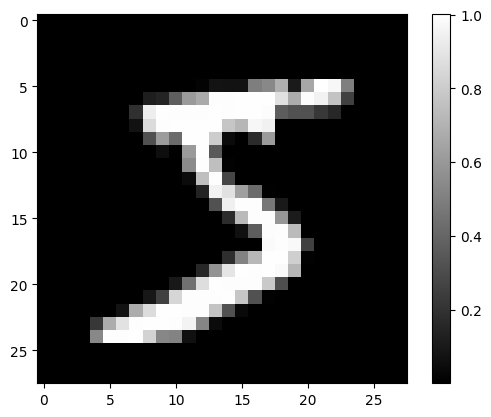

In [4]:
for x, y in training_generator:
    plt.imshow(x[0].reshape(28, 28), cmap='gray')
    plt.colorbar()
    break

In [5]:
from probjax.utils.odeint import _odeint as odeint
from probjax.nn.helpers import SinusoidalEmbedding
from functools import partial



def net(t, x):
    m = UNet2D(out_channels=(16, 32, 64, 128), with_attention=True, num_groups=8)
    x = jnp.array(x).reshape(-1, 28, 28, 1)
    t = jnp.array(t).reshape(-1, 1)
    t = SinusoidalEmbedding(32)(t)
    out =  m(x, t)
    out = out.reshape(out.shape[0], -1)
    return out
    
init, forward = hk.without_apply_rng(hk.transform(net))
params = init(jax.random.PRNGKey(0), jnp.ones(1), jnp.ones((784,)))

ts = jnp.linspace(0, 1, 200)

def drift(t, x, params):
    return forward(params, t, x)


(1, 28, 28, 16)
(1, 14, 14, 32)
(1, 7, 7, 64)
(1, 4, 4, 128)


In [6]:
sigma_min = 1e-2

def loss_fn(params, key, x0):
    """ Optimal transport flow-matching loss.
    """
    key1, key2 = jax.random.split(key, 2)
    t = jax.random.uniform(key1, (x0.shape[0], 1), minval=0, maxval=1)
    x1 = jax.random.normal(key2, x0.shape)

    # One possibility
    # Optimal transport paths
    xt = (1 - (1-sigma_min) * t) * x0  + t*x1
    u = x1 - (1-sigma_min) * x0

    # Diffusion paths
    # beta_min = 0.1 
    # beta_max = 10.
    # alpha_t = jnp.exp(-0.5 * (t*beta_min + 0.5 t**2 * (beta_max - beta_min)))
    # xt = alpha_t * x1 + jnp.sqrt(1- alpha_t**2) * x0
    # u = 

    v_t = jax.vmap(drift, in_axes=(0,0, None))(t, xt, params)
    return jnp.mean(jnp.sum(jnp.square(v_t - u), -1))

In [7]:
@partial(jax.pmap, axis_name="num_devices")
def update(params, opt_state, rng, batch_xs):

    loss, grads = jax.value_and_grad(loss_fn)(params, rng, batch_xs)
    
    grads = jax.lax.pmean(grads, axis_name='num_devices')
    loss = jax.lax.pmean(loss, axis_name='num_devices')
    
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state,loss

In [8]:
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

In [10]:
n_devices = jax.local_device_count()
replicated_params = jax.tree_map(lambda x: jnp.array([x] * n_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * n_devices), opt_state)

In [11]:
key = jax.random.PRNGKey(0)
for i in range(10):
    k = 0
    l = 0
    for xs_batch, _ in training_generator:
        key, subkey = jax.random.split(key)
        xs_batch =  jnp.squeeze(xs_batch)
        xs_batch = jnp.reshape(xs_batch, (jax.device_count(), -1, 784))
        subkey = jax.random.split(subkey, (jax.local_device_count(),  ))
        replicated_params, replicated_opt_state, loss = update(replicated_params, replicated_opt_state, subkey,xs_batch)

        k += 1
        l += loss[0]
        
    print(l/k)

(1, 28, 28, 16)
(1, 14, 14, 32)
(1, 7, 7, 64)
(1, 4, 4, 128)


In [23]:
params = jax.tree_map(lambda x: x[0], replicated_params)


def sample_fn(key, shape):
    z0 = jax.random.normal(key, shape + (784,))
    def f(x0):
        return odeint(lambda t, x: drift(t, x, params), x0, jnp.linspace(0,1, 300), method="bosh3")[-1]
    z1 = jax.vmap(f)(z0)
    return z1

In [24]:
samples = sample_fn(jax.random.PRNGKey(1), (1,))

(1, 28, 28, 16)
(1, 14, 14, 32)
(1, 7, 7, 64)
(1, 4, 4, 128)
(1, 28, 28, 16)
(1, 14, 14, 32)
(1, 7, 7, 64)
(1, 4, 4, 128)
(1, 28, 28, 16)
(1, 14, 14, 32)
(1, 7, 7, 64)
(1, 4, 4, 128)


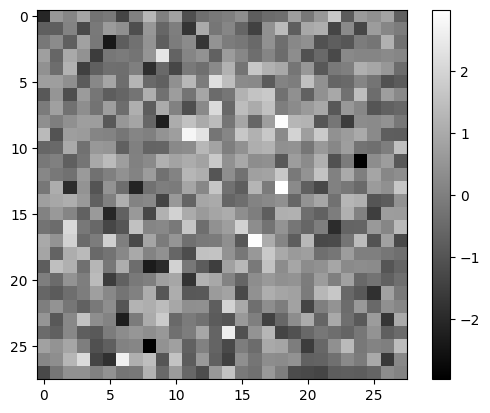

In [25]:
plt.imshow(samples[0].reshape(28, 28), cmap='gray')
plt.colorbar()

In [429]:
plt.imshow(samples[0].reshape(28, 28), cmap='Greys_r')

TypeError: reshape total size must be unchanged, got new_sizes (28, 28) for shape (500, 784).

In [381]:
sigma_min = 1e-1

# Train as if it would be a diffusion process
def loss_fn(params, key, x1):
    """ Optimal transport flow-matching loss.
    """
    key1, key2 = jax.random.split(key, 2)
    t = jax.random.uniform(key1, (x1.shape[0], 1))
    x0 = jax.random.normal(key2, x1.shape)

    # One possibility
    # Optimal transport paths
    # xt = (1 - (1-sigma_min) * t) * x0  + t*x1
    # u = x1 - (1-sigma_min) * x0

    # Diffusion paths
    # beta_min = 0.1 
    # beta_max = 10.
    # alpha_t = jnp.exp(-0.5 * (t*beta_min + 0.5 t**2 * (beta_max - beta_min)))
    # xt = alpha_t * x1 + jnp.sqrt(1- alpha_t**2) * x0
    # u = 

    v_t = jax.vmap(drift, in_axes=(0,0, None))(t, xt, params)
    return jnp.mean(jnp.sum(jnp.square(v_t - u), -1))


    
@jax.jit
def step(params, opt_state, key, x):
    loss, g = jax.value_and_grad(loss_fn)(params, key,x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss


In [382]:
optimizer = adam(5e-4)
opt_state = optimizer.init(params)

In [10]:
key = jax.random.PRNGKey(0)
for i in range(10):
    k = 0
    l = 0
    for xs_batch, _ in training_generator:
        key, subkey = jax.random.split(key)
        params, opt_state, loss = step(params, opt_state, subkey, jnp.squeeze(xs_batch))
        if k > 500:
            break  
        k += 1
        l += loss / 500

    print(l)

NameError: name 'step' is not defined

In [388]:
def sample(params, key, shape):
    z0 = jax.random.normal(key, shape + (784,))
    def f(x0):
        return odeint(lambda t, x: drift(t, x, params), x0, jnp.linspace(0,1, 3000), method="bosh3")[-1]
    z1 = jax.vmap(f)(z0)
    return z1

In [391]:
samples = sample(params, jax.random.PRNGKey(1), (1,))

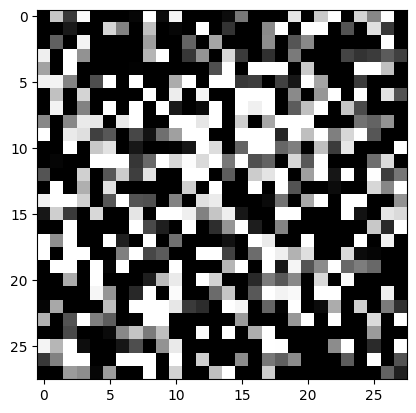

In [392]:
plt.imshow(samples.reshape(28, 28),  cmap="Greys_r", vmin=0, vmax=1)